In [705]:
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from y0.algorithm.ioscm.utils import get_apt_order
from y0.graph import NxMixedGraph

In [706]:
graphml_path = "../ecoli_full_network_no_small_rna.graphml"

In [707]:
g = nx.read_graphml(graphml_path)

In [708]:
total_nodes = len(g.nodes)
total_edges = len(g.edges)
total_nodes, total_edges

(2976, 9211)

In [709]:
out_degree = dict(g.out_degree)
out_degree_list = sorted(list(out_degree.items()), key=lambda x: x[1], reverse=True)
in_degree = dict(g.in_degree)
in_degree_list = sorted(list(in_degree.items()), key=lambda x: x[1], reverse=True)
degree = dict(g.degree)
degree_list = sorted(list(degree.items()), key=lambda x: x[1], reverse=True)

In [710]:
out_degree_list[:20]

[('rpoD', 1662),
 ('crp', 559),
 ('nac', 529),
 ('lrp', 361),
 ('rpoS', 328),
 ('fnr', 320),
 ('fis', 245),
 ('arcA', 231),
 ('ihfA', 227),
 ('ihfB', 227),
 ('hns', 224),
 ('fur', 207),
 ('rpoH', 172),
 ('dksA', 156),
 ('rpoN', 142),
 ('rpoE', 126),
 ('narL', 124),
 ('cpxR', 122),
 ('glaR', 120),
 ('flhC', 92)]

In [711]:
np.unique_counts(list(out_degree.values()))

UniqueCountsResult(values=array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   21,   22,   23,
         24,   26,   27,   28,   30,   32,   33,   37,   38,   42,   43,
         44,   46,   48,   49,   50,   51,   53,   56,   57,   61,   62,
         63,   72,   78,   85,   92,  120,  122,  124,  126,  142,  156,
        172,  207,  224,  227,  231,  245,  320,  328,  361,  529,  559,
       1662]), counts=array([2691,   23,   36,   30,   24,   16,   15,   12,   12,    9,   13,
          6,    7,    5,    6,    6,    1,    4,    2,    3,    1,    2,
          1,    1,    1,    1,    1,    2,    2,    1,    1,    1,    1,
          1,    1,    2,    1,    1,    1,    2,    1,    1,    1,    2,
          1,    1,    1,    1,    2,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    2,    1,    1,    1,    1,    1,    1,    1,
          1]))

In [712]:
(
    min(out_degree.values()),
    np.mean(list(out_degree.values())),
    np.median(list(out_degree.values())),
    max(out_degree.values()),
)

(0, np.float64(3.0950940860215055), np.float64(0.0), 1662)

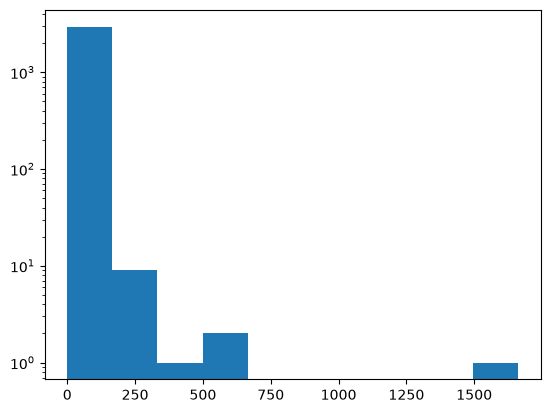

In [713]:
plt.hist(list(out_degree.values()))
plt.yscale("log")

In [714]:
in_degree_list[:20]

[('csgD', 20),
 ('csgE', 20),
 ('csgF', 20),
 ('csgG', 20),
 ('flhC', 17),
 ('flhD', 17),
 ('gadX', 17),
 ('gltF', 16),
 ('rsd', 15),
 ('gadW', 15),
 ('gadA', 14),
 ('gadB', 14),
 ('gltD', 14),
 ('gadE', 14),
 ('gltB', 13),
 ('rmf', 13),
 ('rpoE', 13),
 ('rseA', 13),
 ('fliA', 13),
 ('gadC', 12)]

In [715]:
np.unique_counts(list(in_degree.values()))

UniqueCountsResult(values=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 20]), counts=array([ 54, 821, 671, 470, 315, 231, 143, 114,  54,  37,  23,  14,  10,
         5,   4,   2,   1,   3,   4]))

In [716]:
(
    min(in_degree.values()),
    np.mean(list(in_degree.values())),
    np.median(list(in_degree.values())),
    max(in_degree.values()),
)

(0, np.float64(3.0950940860215055), np.float64(2.0), 20)

(array([ 875., 1141.,  546.,  257.,   91.,   37.,   15.,    6.,    4.,
           4.]),
 array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20.]),
 <BarContainer object of 10 artists>)

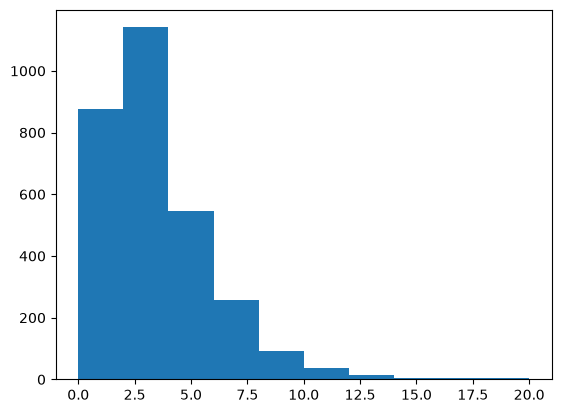

In [717]:
plt.hist(list(in_degree.values()))

In [718]:
degree_list[:20]

[('rpoD', 1667),
 ('crp', 563),
 ('nac', 535),
 ('lrp', 368),
 ('rpoS', 336),
 ('fnr', 326),
 ('fis', 252),
 ('arcA', 234),
 ('ihfA', 232),
 ('ihfB', 232),
 ('hns', 229),
 ('fur', 212),
 ('rpoH', 183),
 ('dksA', 159),
 ('rpoN', 145),
 ('rpoE', 139),
 ('narL', 127),
 ('cpxR', 125),
 ('glaR', 120),
 ('flhC', 109)]

In [719]:
np.unique_counts(list(degree.values()))

UniqueCountsResult(values=array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   22,
         23,   24,   26,   28,   29,   30,   32,   33,   35,   36,   37,
         38,   46,   48,   49,   50,   52,   55,   57,   58,   59,   62,
         64,   65,   66,   67,   80,   85,  109,  120,  125,  127,  139,
        145,  159,  183,  212,  229,  232,  234,  252,  326,  336,  368,
        535,  563, 1667]), counts=array([ 14, 790, 638, 431, 291, 227, 147, 129,  69,  44,  32,  21,  20,
        14,  13,   8,   7,   7,   4,   1,   5,   4,   1,   1,   3,   2,
         1,   1,   1,   1,   2,   1,   1,   1,   2,   3,   1,   1,   3,
         1,   1,   1,   1,   1,   2,   1,   1,   1,   1,   2,   2,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   2,   1,   1,   1,   1,
         1,   1,   1,   1]))

In [720]:
(
    min(degree.values()),
    np.mean(list(degree.values())),
    np.median(list(degree.values())),
    max(degree.values()),
)

(0, np.float64(6.190188172043011), np.float64(3.0), 1667)

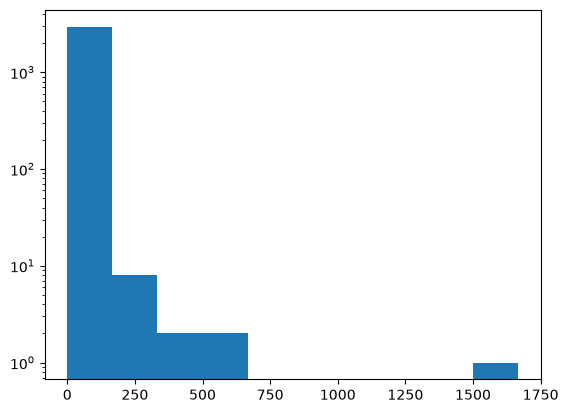

In [721]:
plt.hist(list(degree.values()))
plt.yscale("log")

In [722]:
from collections import Counter

degree_value_counts = Counter(list(degree.values()))
total_nodes = len(degree.values())
degree_value_fraction = [
    count / total_nodes
    for (deg, count) in degree_value_counts.items()
    # if deg < 100
]

In [723]:
def power_func(x, a, gamma):
    return a * x ** (-gamma)

a: 1.0, gamma: 1.0


/var/folders/fh/s3jslwf92j51vj6gd_4hdsh80000gp/T/ipykernel_83734/1519728738.py:2: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-gamma)
/var/folders/fh/s3jslwf92j51vj6gd_4hdsh80000gp/T/ipykernel_83734/1165471252.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  (a, gamma), _ = curve_fit(power_func, x, y)


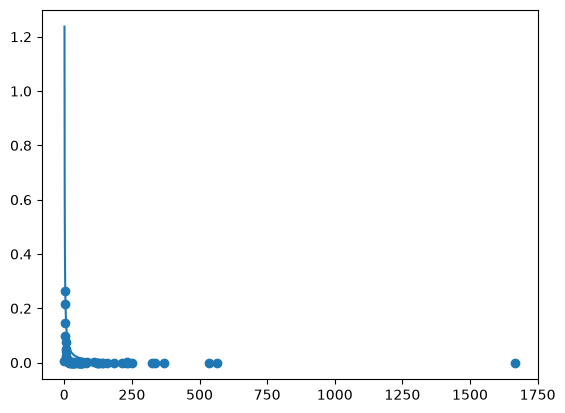

In [724]:
from scipy.optimize import curve_fit

x, y = list(degree_value_counts.keys()), degree_value_fraction

(a, gamma), _ = curve_fit(power_func, x, y)
print(f"a: {a}, gamma: {gamma}")

plt.scatter(x, y)
x = np.linspace(0, 80, 100)
plt.plot(x, power_func(x, a, gamma))

## First subgraph extraction strategy
Pick nodes not from the largest SCC, add in apt-order along with ancestors until N nodes have been added.

In [725]:
sccs = sorted(list(nx.strongly_connected_components(g)), key=lambda x: len(x), reverse=True)
sccs[:5]

[{'acrR',
  'adiY',
  'arcA',
  'argP',
  'argR',
  'bglJ',
  'bolA',
  'cpxR',
  'cra',
  'crp',
  'csgD',
  'cspA',
  'csrA',
  'cytR',
  'deaD',
  'dksA',
  'dnaA',
  'evgA',
  'fis',
  'flhC',
  'flhD',
  'fliA',
  'fliZ',
  'fnr',
  'fur',
  'gadE',
  'gadW',
  'gadX',
  'glnG',
  'hdfR',
  'hns',
  'ihfA',
  'ihfB',
  'leuO',
  'lexA',
  'lldR',
  'lrhA',
  'lrp',
  'matA',
  'mlrA',
  'mqsA',
  'nac',
  'ompR',
  'oxyR',
  'phoB',
  'phoP',
  'qseB',
  'rcsA',
  'rcsB',
  'rpoD',
  'rpoE',
  'rpoH',
  'rpoN',
  'rpoS',
  'rpsA',
  'rstA',
  'rutR',
  'sdiA',
  'slyA',
  'soxR',
  'soxS',
  'stpA',
  'sutR',
  'torR',
  'ydeO',
  'ydiP',
  'yjjQ',
  'zraR'},
 {'marA', 'marR', 'rob'},
 {'accA', 'accD'},
 {'gutM', 'srlR'},
 {'dinJ', 'yafQ'}]

In [726]:
len(sccs[0]), len(sccs[1])

(68, 3)

In [727]:
directed_edges = list(g.edges())
g_mixed = NxMixedGraph.from_edges(directed=directed_edges)

# precompute apt-order once for the full graph
apt_order = [node.name for node in get_apt_order(g_mixed)]
apt_order

['modE',
 'yidZ',
 'glaR',
 'nsrR',
 'ycjW',
 'racR',
 'birA',
 'gatR',
 'ptrR',
 'dicD',
 'cueR',
 'ralA',
 'ulaR',
 'yrdG',
 'basR',
 'yhaJ',
 'btsR',
 'ebgR',
 'fabR',
 'dicF',
 'srmB',
 'zur',
 'c0293',
 'yiaU',
 'yfeC',
 'envY',
 'pgrR',
 'kdpE',
 'rcdA',
 'hypT',
 'deoR',
 'glrR',
 'alpA',
 'citR',
 'nanR',
 'fimZ',
 'nimR',
 'atoC',
 'rclR',
 'pyrR',
 'ameF',
 'envR',
 'selB',
 'nadR',
 'frmR',
 'ygbI',
 'punR',
 'ppiC',
 'kdgT',
 'yadN',
 'yfcV',
 'yfbN',
 'bdcR',
 'yigG',
 'yehS',
 'yfbO',
 'ycgY',
 'hinT',
 'ycbU',
 'yjdP',
 'ynaE',
 'yfjD',
 'ydfI',
 'priC',
 'rsgA',
 'mrdA',
 'ypjA',
 'yehD',
 'yciU',
 'yodB',
 'ypdC',
 'yihM',
 'yidB',
 'yqhC',
 'elfC',
 'yccU',
 'rhsD',
 'orn',
 'hxpA',
 'ydhS',
 'yfbU',
 'ycbV',
 'yfdC',
 'smg',
 'yjfY',
 'tehB',
 'tehA',
 'norR',
 'ycjT',
 'ycjV',
 'ycjO',
 'ompG',
 'ycjQ',
 'ycjR',
 'ycjM',
 'ycjP',
 'ycjU',
 'ycjS',
 'ycjN',
 'ydaV',
 'ydaS',
 'ydaW',
 'yneG',
 'glsB',
 'dicA',
 'cueO',
 'ralR',
 'dgkA',
 'arnE',
 'arnA',
 'arnB',
 'a

In [728]:
dec_from_scc = []
for node in list(sccs[0]):
    dec_from_scc.extend(nx.descendants(g, node) | {node})

dec_from_scc_set = set(dec_from_scc)

In [729]:
len(apt_order)

2961

In [730]:
len(dec_from_scc_set)

2822

In [731]:
candidate_nodes_in_apt_order = list(
    set(apt_order) - dec_from_scc_set
)  # Ignore largest SCCs for apt-ordering
# candidate_nodes_in_apt_order = list(set(apt_order) & (sccs[0] | dec_from_scc_set))  # Use largest SCCs

In [732]:
total_nodes - len(candidate_nodes_in_apt_order)  # total nodes excluded from this subgraph

2837

In [733]:
candidate_nodes_in_apt_order

['yfbU',
 'yhaL',
 'pliG',
 'nanR',
 'ptrR',
 'nadA',
 'deoR',
 'ybjI',
 'ralR',
 'ycjR',
 'rclR',
 'hinT',
 'frmA',
 'nimR',
 'yidB',
 'frmR',
 'arnA',
 'yjfY',
 'c0293',
 'btsR',
 'tehA',
 'punR',
 'ypdC',
 'dicA',
 'adeP',
 'fimZ',
 'glaR',
 'yihM',
 'yiaV',
 'yfjD',
 'nimT',
 'ppiC',
 'sfmC',
 'nsrR',
 'yigG',
 'yiaT',
 'dicD',
 'yidZ',
 'yiaU',
 'ycgY',
 'selA',
 'glsB',
 'glrR',
 'ycjO',
 'yadN',
 'ycjT',
 'ycjW',
 'ygiD',
 'yqhC',
 'arnF',
 'gatR',
 'ynaE',
 'atoC',
 'ulaR',
 'ycjQ',
 'ralA',
 'tehB',
 'ydaS',
 'pnuC',
 'dicF',
 'ybjJ',
 'racR',
 'alpA',
 'pyrR',
 'yfbO',
 'orn',
 'arnT',
 'zur',
 'yjdP',
 'ydfI',
 'norR',
 'cueO',
 'smg',
 'rsgA',
 'kdpE',
 'ycbV',
 'ycjP',
 'ycjU',
 'fabR',
 'punC',
 'ycjV',
 'srmB',
 'priC',
 'arnB',
 'yciU',
 'yfeC',
 'yfdC',
 'yodB',
 'ycbU',
 'dgkA',
 'yhaJ',
 'ycjN',
 'ompG',
 'ygbI',
 'basR',
 'nadR',
 'rcdA',
 'mrdA',
 'bdcR',
 'rhsD',
 'elfC',
 'yehD',
 'mppA',
 'birA',
 'yrdG',
 'sfmA',
 'envY',
 'intA',
 'yfbN',
 'yneG',
 'ydaW',
 'y

In [734]:
len(candidate_nodes_in_apt_order)

139

In [735]:
N = 500

In [736]:
subgraph_nodes = set()

In [737]:
i = 0
while len(subgraph_nodes) < N and i < len(candidate_nodes_in_apt_order):
    node = candidate_nodes_in_apt_order[i]
    subgraph_nodes.add(node)
    ancestors = nx.ancestors(g, node)
    print(f"{len(ancestors)} ancestors for node {node}")
    for anc in nx.ancestors(g, node):
        subgraph_nodes.add(anc)
    i += 1

1 ancestors for node yfbU
1 ancestors for node yhaL
2 ancestors for node pliG
0 ancestors for node nanR
0 ancestors for node ptrR
1 ancestors for node nadA
0 ancestors for node deoR
1 ancestors for node ybjI
1 ancestors for node ralR
1 ancestors for node ycjR
0 ancestors for node rclR
1 ancestors for node hinT
1 ancestors for node frmA
0 ancestors for node nimR
1 ancestors for node yidB
0 ancestors for node frmR
1 ancestors for node arnA
1 ancestors for node yjfY
0 ancestors for node c0293
0 ancestors for node btsR
2 ancestors for node tehA
0 ancestors for node punR
1 ancestors for node ypdC
1 ancestors for node dicA
1 ancestors for node adeP
0 ancestors for node fimZ
0 ancestors for node glaR
1 ancestors for node yihM
1 ancestors for node yiaV
1 ancestors for node yfjD
1 ancestors for node nimT
1 ancestors for node ppiC
1 ancestors for node sfmC
0 ancestors for node nsrR
1 ancestors for node yigG
1 ancestors for node yiaT
0 ancestors for node dicD
0 ancestors for node yidZ
0 ancestors

In [738]:
i

139

In [739]:
subgraph = g.subgraph(subgraph_nodes)

In [740]:
subgraph = g.subgraph(
    [node for node in subgraph_nodes if g.subgraph(subgraph_nodes).degree(node) > 0]
).copy()

In [741]:
print(len(subgraph.edges))
print(len(subgraph.nodes))

104
117


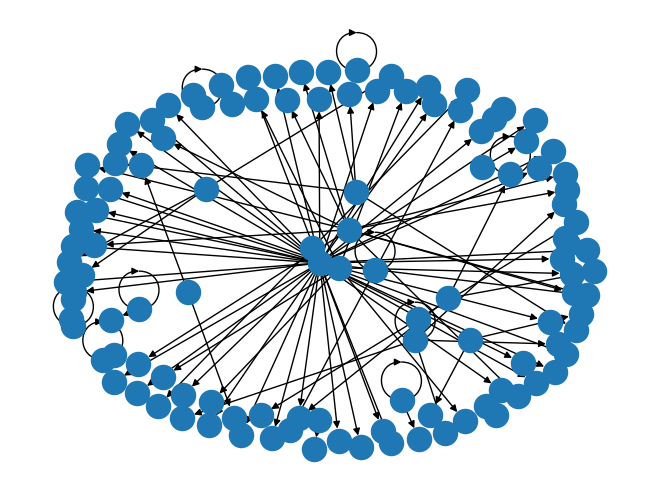

In [742]:
nx.draw(subgraph)

In [743]:
out_degree = dict(subgraph.out_degree)
out_degree_list = sorted(list(out_degree.items()), key=lambda x: x[1], reverse=True)
in_degree = dict(subgraph.in_degree)
in_degree_list = sorted(list(in_degree.items()), key=lambda x: x[1], reverse=True)
degree = dict(subgraph.degree)
degree_list = sorted(list(degree.items()), key=lambda x: x[1], reverse=True)

In [744]:
out_degree_list[:20]

[('glaR', 40),
 ('ycjW', 11),
 ('basR', 8),
 ('yhaJ', 5),
 ('yiaU', 4),
 ('nsrR', 3),
 ('racR', 3),
 ('rcdA', 3),
 ('ptrR', 2),
 ('nimR', 2),
 ('frmR', 2),
 ('fimZ', 2),
 ('nadR', 2),
 ('selB', 2),
 ('citR', 2),
 ('pgrR', 2),
 ('punR', 1),
 ('dicA', 1),
 ('dicD', 1),
 ('yidZ', 1)]

In [745]:
in_degree_list[:20]

[('pliG', 2),
 ('dicA', 2),
 ('tehA', 2),
 ('norR', 2),
 ('ycjP', 2),
 ('yhaL', 1),
 ('yfbU', 1),
 ('nadA', 1),
 ('ybjI', 1),
 ('ralR', 1),
 ('ycjR', 1),
 ('hinT', 1),
 ('nimR', 1),
 ('frmA', 1),
 ('yidB', 1),
 ('frmR', 1),
 ('arnA', 1),
 ('yjfY', 1),
 ('ypdC', 1),
 ('adeP', 1)]

In [746]:
subgraph_sccs = sorted(
    list(nx.strongly_connected_components(subgraph)), key=lambda x: len(x), reverse=True
)
subgraph_sccs

[{'yhaL'},
 {'yfbU'},
 {'pliG'},
 {'nadA'},
 {'glsB'},
 {'yneG'},
 {'ptrR'},
 {'ybjI'},
 {'ralR'},
 {'ycjR'},
 {'hinT'},
 {'nimT'},
 {'nimR'},
 {'frmA'},
 {'yidB'},
 {'frmR'},
 {'arnA'},
 {'yjfY'},
 {'punC'},
 {'punR'},
 {'dicA'},
 {'tehA'},
 {'ypdC'},
 {'adeP'},
 {'bdcR'},
 {'elfC'},
 {'hxpA'},
 {'kdgT'},
 {'mrdA'},
 {'orn'},
 {'priC'},
 {'rhsD'},
 {'rsgA'},
 {'smg'},
 {'yadN'},
 {'ycbU'},
 {'ycbV'},
 {'yccU'},
 {'ycgY'},
 {'yciU'},
 {'ycjP'},
 {'ydfI'},
 {'ydhS'},
 {'yehD'},
 {'yehS'},
 {'yfbN'},
 {'yfbO'},
 {'yfcV'},
 {'yfdC'},
 {'yfjD'},
 {'yigG'},
 {'yihM'},
 {'yjdP'},
 {'ynaE'},
 {'yodB'},
 {'ypjA'},
 {'yqhC'},
 {'glaR'},
 {'sfmA'},
 {'sfmC'},
 {'fimZ'},
 {'yiaV'},
 {'ppiC'},
 {'norR'},
 {'tehB'},
 {'nsrR'},
 {'dicD'},
 {'yiaT'},
 {'yiaW'},
 {'yiaU'},
 {'yidZ'},
 {'selA'},
 {'ycjO'},
 {'ycjT'},
 {'ompG'},
 {'ycjM'},
 {'ycjN'},
 {'ycjQ'},
 {'ycjS'},
 {'ycjU'},
 {'ycjV'},
 {'ycjW'},
 {'ygiD'},
 {'arnF'},
 {'ralA'},
 {'ydaS'},
 {'pnuC'},
 {'ybjJ'},
 {'ydaV'},
 {'ydaW'},
 {'racR'},
 

In [747]:
degree_list[:20]

[('glaR', 40),
 ('ycjW', 11),
 ('basR', 8),
 ('yhaJ', 6),
 ('yiaU', 4),
 ('rcdA', 4),
 ('nimR', 3),
 ('frmR', 3),
 ('dicA', 3),
 ('nsrR', 3),
 ('racR', 3),
 ('norR', 3),
 ('selB', 3),
 ('citR', 3),
 ('pliG', 2),
 ('ptrR', 2),
 ('tehA', 2),
 ('fimZ', 2),
 ('ycjP', 2),
 ('yfeC', 2)]

(array([113.,   2.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1. ,  4.9,  8.8, 12.7, 16.6, 20.5, 24.4, 28.3, 32.2, 36.1, 40. ]),
 <BarContainer object of 10 artists>)

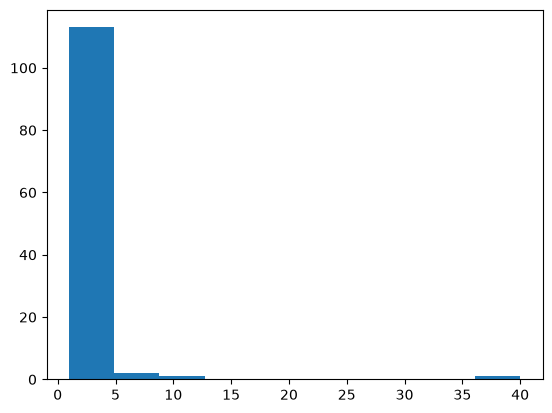

In [748]:
plt.hist(list(degree.values()))

In [749]:
from collections import Counter

degree_value_counts = Counter(list(degree.values()))
total_nodes = len(degree.values())
degree_value_fraction = [
    count / total_nodes
    for (deg, count) in degree_value_counts.items()
    # if deg < 100
]

In [750]:
def power_func(x, a, gamma):
    return a * x ** (-gamma)

a: 0.8110367947759026, gamma: 3.1736488313818665


/var/folders/fh/s3jslwf92j51vj6gd_4hdsh80000gp/T/ipykernel_83734/1519728738.py:2: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-gamma)


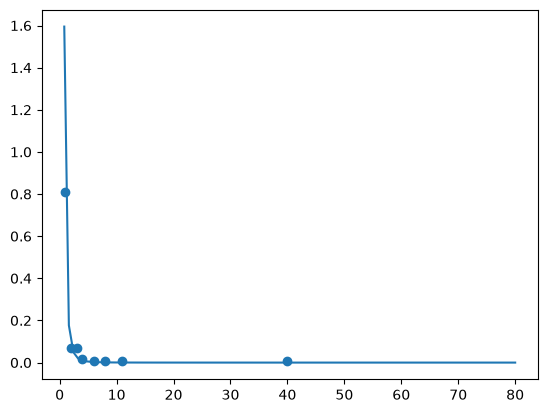

In [751]:
from scipy.optimize import curve_fit

x, y = list(degree_value_counts.keys()), degree_value_fraction

(a, gamma), _ = curve_fit(power_func, x, y)
print(f"a: {a}, gamma: {gamma}")

plt.scatter(x, y)
x = np.linspace(0, 80, 100)
plt.plot(x, power_func(x, a, gamma))

In [752]:
from y0.algorithm.separation.sigma_extension import sigma_extension

from nocap.cyclic_single_door import classify_edge, nx_digraph_to_y0

precomputed_y0 = nx_digraph_to_y0(subgraph)
precomputed_extension = sigma_extension(precomputed_y0)

res = []

self_loop = 0

for cause, effect in subgraph.edges:
    if cause == effect:
        self_loop += 1
        continue
    adj_set = classify_edge(
        subgraph,
        cause,
        effect,
        precomputed_extension=precomputed_extension,
        precomputed_y0=precomputed_y0,
    )
    res.append((cause, effect, adj_set))

In [753]:
self_loop

9

In [754]:
identifiable_edges = [r for r in res if r[2]["status"] == "identifiable"]
unidentifiable_edges = [r for r in res if r[2]["status"] == "unidentifiable"]
len(identifiable_edges), len(unidentifiable_edges)

(95, 0)

In [755]:
sum(e[2]["same_scc"] for e in unidentifiable_edges)

0

In [756]:
sum(len(e[2]["adjustment_set"]) != 0 for e in identifiable_edges)

6

In [757]:
identifiable_edges

[('ptrR',
  'glsB',
  {'cause': 'ptrR',
   'effect': 'glsB',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('ptrR',
  'yneG',
  {'cause': 'ptrR',
   'effect': 'yneG',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('nimR',
  'nimT',
  {'cause': 'nimR',
   'effect': 'nimT',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('frmR',
  'frmA',
  {'cause': 'frmR',
   'effect': 'frmA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('punR',
  'punC',
  {'cause': 'punR',
   'effect': 'punC',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('glaR',
  'bdcR',
  {'cause': 'glaR',
   'effect': 'bdcR',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('glaR',
  'elfC',
  {'cause': 'glaR',
   'effect': 'elfC',
   'status': 'identifiable',
   'adjustment_set': f

In [758]:
from nocap.cyclic_single_door import maximize_identifiable_edges

res = maximize_identifiable_edges(subgraph, k=3)

In [759]:
res

{'curve': [(0, 95)],
 'chosen_nodes': [],
 'final_graph': <networkx.classes.digraph.DiGraph at 0x125214050>,
 'final_results': [{'cause': 'ptrR',
   'effect': 'glsB',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'ptrR',
   'effect': 'yneG',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'nimR',
   'effect': 'nimR',
   'status': 'unidentifiable',
   'adjustment_set': None,
   'same_scc': True},
  {'cause': 'nimR',
   'effect': 'nimT',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'frmR',
   'effect': 'frmA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'frmR',
   'effect': 'frmR',
   'status': 'unidentifiable',
   'adjustment_set': None,
   'same_scc': True},
  {'cause': 'punR',
   'effect': 'punC',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False

## Second subgraph extraction strategy
Pick N random edges from the graph, determine the adjustment sets for every edge and include those nodes. This ensures that causal effects can be recovered and also so no latent confounders are present for the identifiable edges.

In [760]:
N = 50

In [761]:
# Randomly pick edges in the graph, calculate adjustment set and ensure that those nodes are present
random.seed(142)
random_edges = random.sample(sorted(g.edges), k=N)

In [762]:
candidate_nodes = []

In [763]:
precomputed_y0 = nx_digraph_to_y0(g)
precomputed_extension = sigma_extension(precomputed_y0)

self_loop = 0
for node1, node2 in random_edges:
    if cause == effect:
        self_loop += 1
        continue
    adj_set = classify_edge(
        g, cause, effect, precomputed_extension=precomputed_extension, precomputed_y0=precomputed_y0
    )
    candidate_nodes.extend([node1, node2, *adj_set["adjustment_set"]])

print(f"{self_loop} self loops")

0 self loops


In [764]:
candidate_nodes_set = set(candidate_nodes)
candidate_nodes_set

{'alaX',
 'appY',
 'argR',
 'artJ',
 'btsR',
 'chbA',
 'citE',
 'cpxR',
 'crp',
 'csgA',
 'cusR',
 'cyoE',
 'dapD',
 'dinJ',
 'dksA',
 'entB',
 'fecE',
 'fimH',
 'fis',
 'fkpA',
 'flhC',
 'flhD',
 'fur',
 'gadX',
 'gatA',
 'glaR',
 'glsA',
 'gnsA',
 'hns',
 'hyaC',
 'iclR',
 'ihfB',
 'lexA',
 'lrp',
 'malM',
 'marA',
 'mdtA',
 'modE',
 'mqo',
 'nac',
 'nagC',
 'napC',
 'narL',
 'nemA',
 'nemR',
 'nhaR',
 'nirD',
 'norW',
 'nrfG',
 'nuoA',
 'ompR',
 'oxyR',
 'patA',
 'phoB',
 'pinQ',
 'prpR',
 'pstB',
 'pyrB',
 'rclA',
 'rimK',
 'rob',
 'rpmG',
 'rpoD',
 'rpoE',
 'rpoN',
 'rpoS',
 'rpsF',
 'rpsU',
 'rseC',
 'slyA',
 'sufD',
 'tyrP',
 'umuC',
 'uspB',
 'yagU',
 'ybhL',
 'yfaE',
 'yfeC',
 'ygaV'}

In [765]:
len(candidate_nodes_set)

79

In [766]:
subgraph = nx.subgraph(g, candidate_nodes)

In [767]:
len(subgraph.nodes), len(subgraph.edges)

(79, 267)

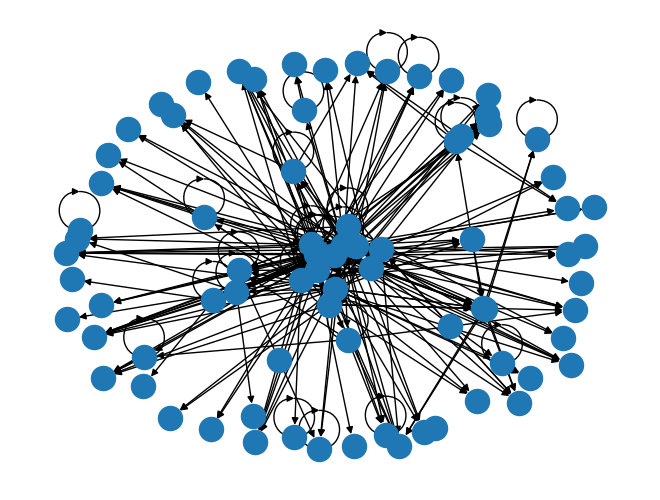

In [768]:
nx.draw(subgraph)

In [769]:
out_degree = dict(subgraph.out_degree)
out_degree_list = sorted(list(out_degree.items()), key=lambda x: x[1], reverse=True)
in_degree = dict(subgraph.in_degree)
in_degree_list = sorted(list(in_degree.items()), key=lambda x: x[1], reverse=True)
degree = dict(subgraph.degree)
degree_list = sorted(list(degree.items()), key=lambda x: x[1], reverse=True)

In [770]:
out_degree_list[:20]

[('rpoD', 55),
 ('crp', 25),
 ('ihfB', 17),
 ('rpoS', 15),
 ('fis', 14),
 ('nac', 14),
 ('lrp', 11),
 ('fur', 10),
 ('hns', 10),
 ('dksA', 9),
 ('rpoN', 8),
 ('cpxR', 8),
 ('narL', 7),
 ('rpoE', 6),
 ('lexA', 5),
 ('phoB', 5),
 ('gadX', 4),
 ('rob', 4),
 ('marA', 4),
 ('oxyR', 4)]

In [771]:
in_degree_list[:20]

[('gadX', 9),
 ('rseC', 8),
 ('rpoE', 8),
 ('flhC', 7),
 ('flhD', 7),
 ('nrfG', 7),
 ('napC', 6),
 ('marA', 6),
 ('nuoA', 6),
 ('nirD', 6),
 ('yfaE', 5),
 ('cyoE', 5),
 ('fimH', 5),
 ('patA', 5),
 ('lrp', 5),
 ('fis', 5),
 ('rpoS', 5),
 ('hyaC', 5),
 ('pstB', 5),
 ('ompR', 4)]

In [772]:
subgraph_sccs = sorted(
    list(nx.strongly_connected_components(subgraph)), key=lambda x: len(x), reverse=True
)
subgraph_sccs

[{'argR',
  'cpxR',
  'crp',
  'dksA',
  'fis',
  'fur',
  'gadX',
  'hns',
  'ihfB',
  'lexA',
  'lrp',
  'nac',
  'oxyR',
  'phoB',
  'rpoD',
  'rpoE',
  'rpoN',
  'rpoS'},
 {'marA', 'rob'},
 {'mqo'},
 {'dinJ'},
 {'alaX'},
 {'hyaC'},
 {'appY'},
 {'artJ'},
 {'fimH'},
 {'glsA'},
 {'iclR'},
 {'napC'},
 {'nrfG'},
 {'flhC'},
 {'flhD'},
 {'nhaR'},
 {'nirD'},
 {'yfaE'},
 {'csgA'},
 {'dapD'},
 {'rimK'},
 {'mdtA'},
 {'nuoA'},
 {'fkpA'},
 {'rclA'},
 {'gnsA'},
 {'norW'},
 {'patA'},
 {'rseC'},
 {'chbA'},
 {'citE'},
 {'cyoE'},
 {'rpmG'},
 {'rpsU'},
 {'entB'},
 {'fecE'},
 {'pstB'},
 {'sufD'},
 {'gatA'},
 {'malM'},
 {'nagC'},
 {'ompR'},
 {'prpR'},
 {'rpsF'},
 {'tyrP'},
 {'uspB'},
 {'cusR'},
 {'pinQ'},
 {'pyrB'},
 {'yagU'},
 {'ygaV'},
 {'slyA'},
 {'narL'},
 {'nemA'},
 {'nemR'},
 {'umuC'},
 {'ybhL'},
 {'btsR'},
 {'glaR'},
 {'yfeC'},
 {'modE'}]

In [773]:
degree_list[:20]

[('rpoD', 59),
 ('crp', 28),
 ('ihfB', 21),
 ('rpoS', 20),
 ('fis', 19),
 ('nac', 18),
 ('lrp', 16),
 ('fur', 14),
 ('hns', 14),
 ('rpoE', 14),
 ('gadX', 13),
 ('dksA', 12),
 ('rpoN', 11),
 ('cpxR', 11),
 ('flhC', 10),
 ('flhD', 10),
 ('marA', 10),
 ('narL', 9),
 ('phoB', 8),
 ('rseC', 8)]

(array([54., 14.,  6.,  3.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([ 1. ,  6.8, 12.6, 18.4, 24.2, 30. , 35.8, 41.6, 47.4, 53.2, 59. ]),
 <BarContainer object of 10 artists>)

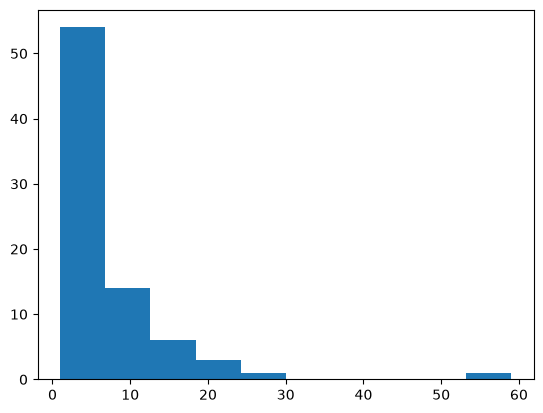

In [774]:
plt.hist(list(degree.values()))

In [775]:
degree.values()

dict_values([1, 7, 7, 8, 5, 28, 1, 3, 1, 9, 13, 10, 2, 5, 1, 3, 2, 1, 11, 2, 5, 6, 2, 3, 14, 1, 2, 4, 3, 2, 4, 10, 14, 8, 5, 12, 5, 2, 4, 5, 14, 5, 5, 3, 6, 4, 2, 4, 3, 4, 7, 16, 4, 10, 3, 19, 11, 5, 1, 2, 8, 2, 20, 5, 5, 6, 6, 5, 3, 2, 1, 2, 7, 21, 59, 2, 2, 1, 18])

In [776]:
from collections import Counter

degree_value_counts = Counter(list(degree.values()))
total_nodes = len(degree.values())
degree_value_fraction = [
    count / total_nodes
    for (deg, count) in degree_value_counts.items()
    # if deg < 100
]

In [777]:
def power_func(x, a, gamma):
    return a * x ** (-gamma)

a: 0.16640923403931338, gamma: 0.6055234716875741


/var/folders/fh/s3jslwf92j51vj6gd_4hdsh80000gp/T/ipykernel_83734/1519728738.py:2: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-gamma)


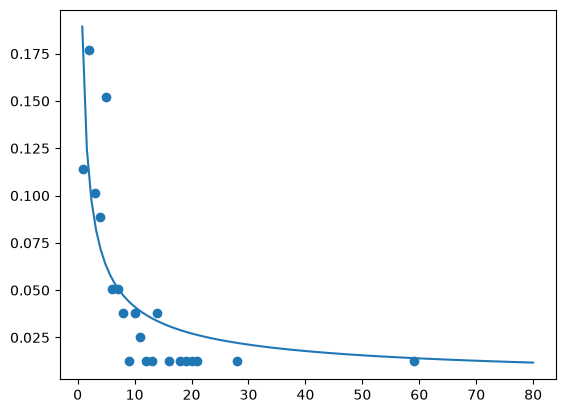

In [778]:
from scipy.optimize import curve_fit

x, y = list(degree_value_counts.keys()), degree_value_fraction

(a, gamma), _ = curve_fit(power_func, x, y)
print(f"a: {a}, gamma: {gamma}")

plt.scatter(x, y)
x = np.linspace(0, 80, 100)
plt.plot(x, power_func(x, a, gamma))

In [779]:
from y0.algorithm.separation.sigma_extension import sigma_extension

from nocap.cyclic_single_door import classify_edge, nx_digraph_to_y0

precomputed_y0 = nx_digraph_to_y0(subgraph)
precomputed_extension = sigma_extension(precomputed_y0)

res = []

self_loop = 0

for cause, effect in subgraph.edges:
    if cause == effect:
        self_loop += 1
        continue
    adj_set = classify_edge(
        subgraph,
        cause,
        effect,
        precomputed_extension=precomputed_extension,
        precomputed_y0=precomputed_y0,
    )
    res.append((cause, effect, adj_set))

In [780]:
self_loop

28

In [781]:
identifiable_edges = [r for r in res if r[2]["status"] == "identifiable"]
unidentifiable_edges = [r for r in res if r[2]["status"] == "unidentifiable"]
len(identifiable_edges), len(unidentifiable_edges)

(178, 61)

In [782]:
sum(e[2]["same_scc"] for e in unidentifiable_edges)

61

In [783]:
sum(len(e[2]["adjustment_set"]) != 0 for e in identifiable_edges)

177

In [784]:
identifiable_edges

[('lexA',
  'dinJ',
  {'cause': 'lexA',
   'effect': 'dinJ',
   'status': 'identifiable',
   'adjustment_set': frozenset({'argR',
              'cpxR',
              'crp',
              'dksA',
              'fis',
              'fur',
              'gadX',
              'glaR',
              'hns',
              'ihfB',
              'lrp',
              'nac',
              'oxyR',
              'phoB',
              'rpoD',
              'rpoE',
              'rpoN',
              'rpoS'}),
   'same_scc': False}),
 ('lexA',
  'rpsU',
  {'cause': 'lexA',
   'effect': 'rpsU',
   'status': 'identifiable',
   'adjustment_set': frozenset({'argR',
              'cpxR',
              'crp',
              'dksA',
              'fis',
              'fur',
              'gadX',
              'glaR',
              'hns',
              'ihfB',
              'lrp',
              'nac',
              'oxyR',
              'phoB',
              'rpoD',
              'rpoE',
              'rpoN',


(array([ 4.,  4., 10.,  7.,  4.,  0.,  0., 95., 42., 12.]),
 array([ 0. ,  2.3,  4.6,  6.9,  9.2, 11.5, 13.8, 16.1, 18.4, 20.7, 23. ]),
 <BarContainer object of 10 artists>)

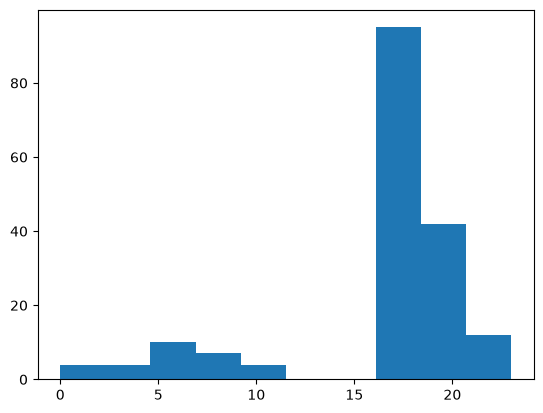

In [785]:
adj_set_size = []

for n1, n2, adj_set in identifiable_edges:
    adj_set_size.append(len(adj_set["adjustment_set"]))

plt.hist(adj_set_size)

In [786]:
from nocap.cyclic_single_door import maximize_identifiable_edges

res = maximize_identifiable_edges(subgraph, k=3)
res

{'curve': [(0, 178), (1, 181), (2, 183), (3, 193)],
 'chosen_nodes': ['fur', 'lrp', 'rpoS'],
 'final_graph': <networkx.classes.digraph.DiGraph at 0x11c3a23f0>,
 'final_results': [{'cause': 'lexA',
   'effect': 'dinJ',
   'status': 'identifiable',
   'adjustment_set': frozenset({'cpxR',
              'crp',
              'dksA',
              'fis',
              'fur',
              'ihfB',
              'lrp',
              'nac',
              'rpoD',
              'rpoE',
              'rpoN',
              'rpoS'}),
   'same_scc': False},
  {'cause': 'lexA',
   'effect': 'lexA',
   'status': 'unidentifiable',
   'adjustment_set': None,
   'same_scc': True},
  {'cause': 'lexA',
   'effect': 'rpoD',
   'status': 'unidentifiable',
   'adjustment_set': None,
   'same_scc': True},
  {'cause': 'lexA',
   'effect': 'rpsU',
   'status': 'identifiable',
   'adjustment_set': frozenset({'cpxR',
              'crp',
              'dksA',
              'fis',
              'ihfB',
             

In [787]:
nx.write_graphml(subgraph, path=f"ecoli_n-{N}_sub_network_no_small_rna.graphml", prettyprint=True)